In [ ]:
# Install required Python libraries for:
# - OCR (pytesseract + tesseract-ocr system tool)
# - Audio transcription (openai-whisper)
# - Video processing (moviepy)
# - Text summarization (transformers)
!pip install -q pytesseract transformers moviepy openai-whisper
!sudo apt install -y tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
!pip install -q pytube moviepy

In [ ]:
!pip install yt-dlp moviepy

In [ ]:
!yt-dlp -f mp4 --downloader ffmpeg --downloader-args "ffmpeg_i:-t 00:00:30" \
"https://www.youtube.com/watch?v=jOV0eI7wNiw" -o "poilievre_french_clip.%(ext)s"

[youtube] Extracting URL: https://www.youtube.com/watch?v=jOV0eI7wNiw
[youtube] jOV0eI7wNiw: Downloading webpage
[youtube] jOV0eI7wNiw: Downloading tv client config
[youtube] jOV0eI7wNiw: Downloading tv player API JSON
[youtube] jOV0eI7wNiw: Downloading ios player API JSON
[youtube] jOV0eI7wNiw: Downloading m3u8 information
[info] jOV0eI7wNiw: Downloading 1 format(s): 18
[download] poilievre_french_clip.mp4 has already been downloaded
[download] 100% of    1.35MiB


In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Load and encode the video
mp4_file = open("poilievre_french_clip.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4_file).decode()

# Display it with an HTML video tag
HTML(f"""
<video width=480 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
from moviepy.editor import VideoFileClip

# Load the full 30s clip
clip = VideoFileClip("poilievre_french_clip.mp4")

# Extract the 1-second segment from 12 to 13 seconds
short_clip = clip.subclip(11, 14)

# Save the new 1-second clip
short_clip.write_videofile("poilievre_french_12_13.mp4", codec="libx264")

Moviepy - Building video poilievre_french_12_13.mp4.
MoviePy - Writing audio in poilievre_french_12_13TEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video poilievre_french_12_13.mp4



Moviepy - Done !
Moviepy - video ready poilievre_french_12_13.mp4


In [ ]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("poilievre_french_12_13.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=480 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

🔍 FPS: 23.98, Total Frames: 72


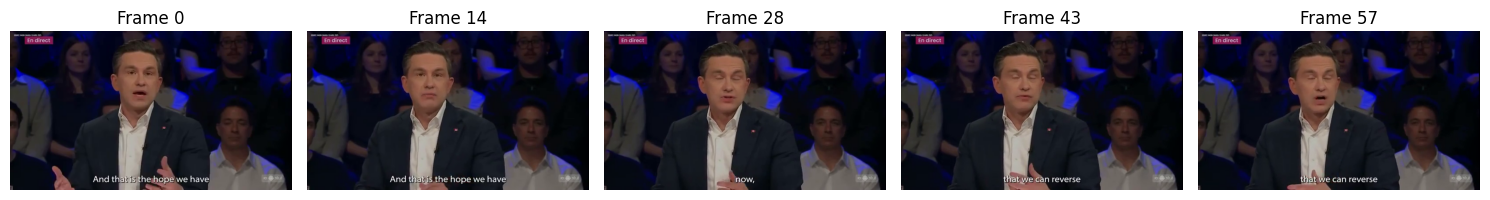

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the video (1-second clip: 12s–13s)
video_path = "poilievre_french_12_13.mp4"
cap = cv2.VideoCapture(video_path)

# Get FPS and total frames
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"🔍 FPS: {fps}, Total Frames: {total_frames}")

# Extract evenly spaced frames (e.g., 5 frames from the 1-second clip)
frame_indices = [int(i * total_frames / 5) for i in range(5)]

# Plot the selected frames
plt.figure(figsize=(15, 4))
for i, frame_idx in enumerate(frame_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i+1)
        plt.imshow(frame_rgb)
        plt.axis('off')
        plt.title(f"Frame {frame_idx}")
cap.release()
plt.tight_layout()
plt.show()

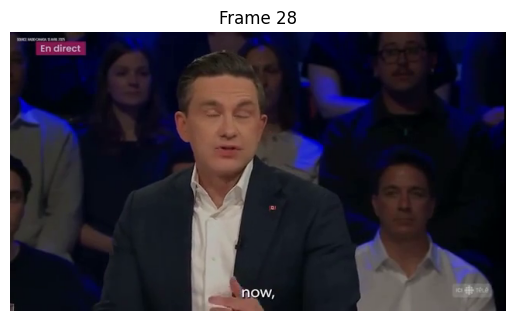

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the 1-second video clip
cap = cv2.VideoCapture("poilievre_french_12_13.mp4")

# Set video to frame 28
cap.set(cv2.CAP_PROP_POS_FRAMES, 28)
ret, frame = cap.read()
cap.release()

# Display the frame if successful
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.title("Frame 28")
    plt.show()
else:
    print("❌ Could not retrieve frame 28.")

In [ ]:
import pytesseract

# Convert BGR to RGB and run OCR
ocr_text = pytesseract.image_to_string(frame_rgb)
print("📝 OCR Extracted Text:\n", ocr_text.strip())

📝 OCR Extracted Text:
 


In [ ]:
import os

# Confirm if file exists at the expected path
image_path = "/mnt/data/2e83783f-9d1b-49cd-95f6-1bb9cb54477e.png"
print("✅ File exists:", os.path.exists(image_path))

✅ File exists: False


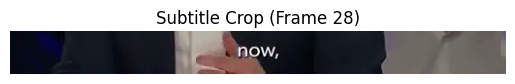

📝 OCR Result: 


In [ ]:
import cv2
import pytesseract
import matplotlib.pyplot as plt

# Load the video
cap = cv2.VideoCapture("poilievre_french_12_13.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 28)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("❌ Could not extract frame 28.")


h, w, _ = frame.shape
# Wider crop: bottom 12% of height, 80% width across the bottom
y1, y2 = int(h * 0.88), h
x1, x2 = int(w * 0.1), int(w * 0.9)
subtitle_crop = frame[y1:y2, x1:x2]
subtitle_crop = frame[y1:y2, x1:x2]

# Display cropped subtitle
subtitle_rgb = cv2.cvtColor(subtitle_crop, cv2.COLOR_BGR2RGB)
plt.imshow(subtitle_rgb)
plt.axis('off')
plt.title("Subtitle Crop (Frame 28)")
plt.show()

# OCR the cropped subtitle
ocr_result = pytesseract.image_to_string(subtitle_rgb)
print("📝 OCR Result:", ocr_result.strip())

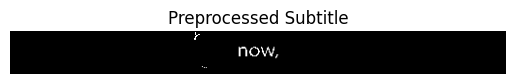

📝 OCR Result (Improved): now,


In [ ]:
# Convert to grayscale and increase contrast
gray = cv2.cvtColor(subtitle_crop, cv2.COLOR_BGR2GRAY)

# Optional: apply thresholding (binary)
_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

# Visual check
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.title("Preprocessed Subtitle")
plt.show()

# Run OCR on thresholded image
ocr_result = pytesseract.image_to_string(thresh)
print("📝 OCR Result (Improved):", ocr_result.strip())

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

# Load the tokenizer and model
model_name = 'Helsinki-NLP/opus-mt-tc-big-en-ko'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# English text to translate
english_text = "now"

# Prepare the text for translation
inputs = tokenizer(english_text, return_tensors="pt", padding=True)

# Perform the translation
translated = model.generate(**inputs)

# Decode the translated text
korean_text = tokenizer.decode(translated[0], skip_special_tokens=True)

print(f"📤 English: {english_text}")
print(f"📥 Korean: {korean_text}")

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(

  warnings.warn("Recommended: pip install sacremoses.")



📤 English: now
📥 Korean: 조선민주주의인민공화국


In [ ]:
!pip install googletrans==4.0.0-rc1

from googletrans import Translator

translator = Translator()
result = translator.translate("now", src="en", dest="ko")
print(f"📤 English: now")
print(f"📥 Korean: {result.text}")

📤 English: now
📥 Korean: 지금


In [ ]:
##########################################################################

In [ ]:
!pip install yt-dlp
!sudo apt install -y ffmpeg

# Download only the first 30 seconds (to keep it light)
!yt-dlp -f mp4 --downloader ffmpeg --downloader-args "ffmpeg_i:-t 00:00:30" \
"https://www.youtube.com/shorts/blfFVII9juc" -o "poilievre_food_prices.%(ext)s"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
[youtube] Extracting URL: https://www.youtube.com/shorts/blfFVII9juc
[youtube] blfFVII9juc: Downloading webpage
[youtube] blfFVII9juc: Downloading tv client config
[youtube] blfFVII9juc: Downloading tv player API JSON
[youtube] blfFVII9juc: Downloading ios player API JSON
[youtube] blfFVII9juc: Downloading m3u8 information
[info] blfFVII9juc: Downloading 1 format(s): 18
[download] poilievre_food_prices.mp4 has already been downloaded
[download] 100% of    2.14MiB


In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Load and encode the video to base64
mp4 = open("poilievre_food_prices.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

# Embed video player
HTML(f"""
<video width=480 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
!pip install git+https://github.com/openai/whisper.git

import whisper

# Load the Whisper model (you can use "base" or "small" for faster results)
model = whisper.load_model("base")

# Transcribe the downloaded video
result = model.transcribe("poilievre_food_prices.mp4")
transcribed_text = result['text']
print("📝 Transcribed Text:\n", transcribed_text)

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-0r2u7a_j
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-0r2u7a_j
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



📝 Transcribed Text:
  This Canadian politician completely destroyed this woke interviewer with facts. I wonder what message you're sending to Canadians, Mr. Polly Ev. When you say you're all about acting the tax. I mean, the same breath you say. You're not sure you're going to support a tax break. At a time when they're struggling so badly. Structling so badly. It's been nine years that Trudeau's promised to make them better off. And here we are. You're right. They are struggling so badly. Food prices rising 37% faster in Canada. Then they have in the United States just as the carbon tax came. Housing costs double. That was never the case before just in Trudeau.


In [ ]:
!pip install serpapi

In [ ]:
!pip install google-search-results

In [ ]:
from serpapi import GoogleSearch
from getpass import getpass

# 🔐 Securely prompt for API key (hidden input)
api_key = getpass("Enter your SerpAPI key (hidden): ")

Enter your SerpAPI key (hidden): ··········


In [ ]:
from transformers import pipeline

# Load small generative model
query_generator = pipeline("text2text-generation", model="google/flan-t5-small")

# Prompt the model
prompt = f"Generate a Google search query to fact-check this claim: {transcribed_text}"
search_query = query_generator(prompt, max_length=64)[0]['generated_text']
print("🔍 Generated Search Query:\n", search_query)

Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔍 Generated Search Query:
 It's been nine years that Trudeau promised to make them better off. And here we are. You're right. They are struggling so badly. Food prices rising 37% faster in Canada. Then they have in the United States just as the carbon tax came. Housing costs double. That was never the case before just in Trudeau.


In [ ]:
params = {
    "engine": "google",
    "q": search_query,
    "api_key": api_key,
    "num": 2  # Number of results to return
}

search = GoogleSearch(params)
results = search.get_dict()

# Print top 3 search results
for i, result in enumerate(results.get("organic_results", [])[:3]):
    print(f"\n🔗 Result {i+1}")
    print("Title:", result.get("title"))
    print("Link:", result.get("link"))
    print("Snippet:", result.get("snippet", "No summary available."))


🔗 Result 1
Title: After 9 years of Justin Trudeau and the NDP, food ...
Link: https://www.facebook.com/PierrePoilievreMP/posts/after-9-years-of-justin-trudeau-and-the-ndp-food-insecurity-is-almost-70-higher-/1091920932295758/
Snippet: After 9 years of Justin Trudeau and the NDP, food insecurity is almost 70% higher in Canada than in the United States.

🔗 Result 2
Title: Justin Trudeau Has Impoverished Canadians
Link: https://www.conservative.ca/just-the-facts-justin-trudeau-has-impoverished-canadians/?utm_content=national/news/page/2
Snippet: Ottawa, ON – After nine years of Justin Trudeau, life has never been so hard for Canadians. Food will cost families $700 more this year than it did in 2023 ...
